In [109]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import rfft, rfftfreq
from scipy.signal import detrend, find_peaks
import os
from scipy.interpolate import interp1d


In [79]:
# Constants
G = 4 * np.pi**2           # AU^3/yr^2/M_sun -- G=4pi^2 so Earth's period = 1 year at a = 1 AU
S0 = 1361                  # solar constant (W/m^2)

M_SUN = 1.0
M_EARTH = 3.003e-6         # in solar mass
M_JUPITER = 9.545e-4       # in solar mass

EARTH_R0 = 1.0             # AU
EARTH_V0 = 2 * np.pi       # AU/yr (circular orbital velocity)
EARTH_V0_ECCENTRIC = 2 * np.pi * 1.01

JUPITER_R0 = 5.2           # AU
JUPITER_V0 = 2 * np.pi / np.sqrt(JUPITER_R0)   # AU/yr

SOFTENING = 0.01           # AU (1% of Earth-Sun distance)

In [80]:
#Acceleration (2D)
def acceleration(positions, masses, softening=SOFTENING):
    diff = positions[np.newaxis, :, :] - positions[:, np.newaxis, :]
    dist_sq = np.sum(diff**2, axis=-1) + softening**2

    inv_dist_cube = dist_sq**(-1.5)
    np.fill_diagonal(inv_dist_cube, 0.0)
    
    acc = G * np.sum(masses[np.newaxis, :, np.newaxis] * diff * inv_dist_cube[:, :, np.newaxis], axis=1)
    return acc

In [81]:
# Integrators
def rk4_step(positions, velocities, masses, dt):
    a1 = acceleration(positions, masses, G)
    a2 = acceleration(positions + 0.5 * dt * velocities, masses, G)
    a3 = acceleration(positions + 0.5 * dt * (velocities + 0.5 * dt * a1), masses, G)
    a4 = acceleration(positions + dt * (velocities + 0.5 * dt * a2), masses, G)
    
    new_positions = positions + (dt/6.0) * (velocities + 2*(velocities + 0.5*dt*a1) + 2*(velocities + 0.5*dt*a2) + (velocities + dt*a3))
    new_velocities = velocities + (dt/6.0) * (a1 + 2*a2 + 2*a3 + a4)
    
    return new_positions, new_velocities

def leapfrog_step(positions, velocities, masses, dt):
    positions_new = positions + dt * velocities
    acc_new = acceleration(positions_new, masses)
    velocities_new = velocities + dt * acc_new

    return positions_new, velocities_new

In [82]:
# Energy and Angular Momentum
def total_energy(positions, velocities, masses):
    N = len(masses)
    kinetic = 0.5 * np.sum(masses * np.sum(velocities**2, axis=1))

    potential = 0
    for i in range(N):
        for j in range(i+1, N):
            r = np.linalg.norm(positions[i] - positions[j])
            potential -= G * masses[i] * masses[j] / r
    return kinetic + potential


def total_angular_momentum(positions, velocities, masses):
    L = 0
    for i in range(len(masses)):
        r = positions[i]
        v = velocities[i]
        L += masses[i] * (r[0]*v[1] - r[1]*v[0])
    return L

In [83]:
# # Orbital Elements from State Vectors
# def compute_orbital_elements(pos_body, vel_body, M_central=M_SUN):
#     r = np.linalg.norm(pos_body)
#     v = np.linalg.norm(vel_body)
#     mu = G * M_central

#     h_vec = pos_body[0]*vel_body[1] - pos_body[1]*vel_body[0]
#     h = np.abs(h_vec)

#     E_spec = 0.5 * v**2 - mu / r

#     if E_spec < 0:     # negative energy = bound orbit
#         a = -mu / (2 * E_spec)
#     else:
#         a = np.inf

#     e = np.sqrt(1 + (2 * E_spec * h**2) / mu**2)
#     r_dot_v = pos_body[0]*vel_body[0] + pos_body[1]*vel_body[1]

#     e_vec_x = (vel_body[1] * h - mu * pos_body[0]/r) / mu
#     e_vec_y = (-vel_body[0] * h - mu * pos_body[1]/r) / mu

#     true_anomaly = np.arctan2(e_vec_y, e_vec_x)

#     return {
#         'a': a,
#         'e': e,
#         'h': h,
#         'E': E_spec,
#         'theta': true_anomaly
#     }

In [84]:
def compute_orbital_elements(pos, vel, M_central=1.0, G=4*np.pi**2):
    r = np.linalg.norm(pos)
    v = np.linalg.norm(vel)
    mu = G * M_central

    # specific angular momentum (2D scalar)
    h = pos[0]*vel[1] - pos[1]*vel[0]

    # specific orbital energy
    E = 0.5*v*v - mu/r

    # semi-major axis
    a = -mu/(2*E)

    # eccentricity
    e = np.sqrt(1 + 2*E*h*h/mu**2)

    return a, e

In [85]:
def nbody_rk4(positions, velocities, masses, dt, steps):
    N = len(masses)
    pos_hist = np.zeros((steps, N, 2))
    vel_hist = np.zeros((steps, N, 2))

    pos = positions.copy()
    vel = velocities.copy()

    for i in range(steps):
        pos_hist[i] = pos
        vel_hist[i] = vel
        pos, vel = rk4_step(pos, vel, masses, dt)

    return pos_hist, vel_hist

In [86]:
def run_simulation(integrator, dt, steps, bodies='sun_earth_jupiter',
                   eccentric_init=False):
    if bodies == 'sun_earth':
        masses = np.array([M_SUN, M_EARTH])
        positions = np.array([
            [0.0, 0.0],
            [EARTH_R0, 0.0],
        ])

        v_earth = np.array([0.0, EARTH_V0])
        v_sun = - (M_EARTH / M_SUN) * v_earth
        
        velocities = np.array([
            v_sun,
            v_earth,
        ])
        
    else:  # sun_earth_jupiter
        masses = np.array([M_SUN, M_EARTH, M_JUPITER])
        positions = np.array([
            [0.0, 0.0],
            [EARTH_R0, 0.0],
            [JUPITER_R0, 0.0],
        ])

        if eccentric_init:
            velocities = np.array([
                [0.0, 0.0],
                [0.0, EARTH_V0_ECCENTRIC],
                [0.0, JUPITER_V0],
            ])
        else:
            velocities = np.array([
                [0.0, 0.0],
                [0.0, EARTH_V0],
                [0.0, JUPITER_V0],
            ])

    # Center-of-mass correction
    total_mass = np.sum(masses)
    x_cm = np.sum(positions * masses[:, None], axis=0) / total_mass
    v_cm = np.sum(velocities * masses[:, None], axis=0) / total_mass
    positions -= x_cm
    velocities -= v_cm

    # Store history
    N = len(masses)
    pos_hist = np.zeros((steps, N, 2))
    vel_hist = np.zeros((steps, N, 2))
    energy_hist = np.zeros(steps)
    angmom_hist = np.zeros(steps)
    ecc_hist = np.zeros(steps)      # Earth's eccentricity
    a_hist = np.zeros(steps)        # Earth's semi-major axis

    pos = positions.copy()
    vel = velocities.copy()
    print(f"Starting simulation for {steps*dt} years...")
    for step in range(steps):
        if step % (steps // 10) == 0:
            print(f" Progress: {100 * step / steps:.0f}% complete...")

        pos_hist[step] = pos
        vel_hist[step] = vel
        energy_hist[step] = total_energy(pos, vel, masses)
        angmom_hist[step] = total_angular_momentum(pos, vel, masses)

        # Compute Earth's orbital elements (relative to Sun)
        earth_idx = 1
        sun_idx = 0
        r_vec = pos[earth_idx] - pos[sun_idx]
        v_vec = vel[earth_idx] - vel[sun_idx]
        elements = compute_orbital_elements(r_vec, v_vec, M_SUN)
        a, e = compute_orbital_elements(r_vec, v_vec)
        ecc_hist[step] = e
        a_hist[step] = a

        # Integrate
        pos, vel = integrator(pos, vel, masses, dt)
    print(r"Simulation 100% complete")
    return pos_hist, vel_hist, energy_hist, angmom_hist, ecc_hist, a_hist


In [87]:
def extract_earth_orbit(pos_hist, vel_hist, masses):
    earth_idx = 1
    sun_idx = 0

    r_vec = pos_hist[:, earth_idx] - pos_hist[:, sun_idx]
    r = np.linalg.norm(r_vec, axis=1)
    longitude = np.arctan2(r_vec[:, 1], r_vec[:, 0])
    longitude = np.unwrap(longitude)

    return r, longitude
    

In [88]:
#plots
def plot_compare(time, r_rk4, r_lf, lon_rk4, lon_lf,
                 E_rk4, E_lf, L_rk4, L_lf,
                 ecc_rk4, ecc_lf, a_rk4, a_lf,
                 title_prefix):

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))

    # 1. Energy drift
    axes[0, 0].plot(time, (E_rk4 - E_rk4[0]) / E_rk4[0], 'b-', label='RK4')
    axes[0, 0].plot(time, (E_lf - E_lf[0]) / E_lf[0], 'r-', label='Leapfrog')
    axes[0, 0].set_title(f'{title_prefix}: Energy Drift')
    axes[0, 0].grid(True)

    # 2. Angular momentum drift
    axes[0, 1].plot(time, (L_rk4 - L_rk4[0]) / L_rk4[0], 'b-', label='RK4')
    axes[0, 1].plot(time, (L_lf - L_lf[0]) / L_lf[0], 'r-', label='Leapfrog')
    axes[0, 1].set_title(f'{title_prefix}: Angular Momentum Drift')
    axes[0, 1].grid(True)

    # 3. Eccentricity
    axes[0, 2].plot(time, ecc_rk4, 'b-', label='RK4')
    axes[0, 2].plot(time, ecc_lf, 'r-', label='Leapfrog')
    axes[0, 2].set_title(f'{title_prefix}: Eccentricity')
    axes[0, 2].grid(True)

    # 4. Radius deviation
    axes[1, 0].plot(time, r_rk4 - 1.0, 'b-', label='RK4')
    axes[1, 0].plot(time, r_lf - 1.0, 'r-', label='Leapfrog')
    axes[1, 0].set_title(f'{title_prefix}: Radius Deviation')
    axes[1, 0].grid(True)

    # 5. Longitude deviation
    mean_motion = 2 * np.pi
    lon_trend = mean_motion * time
    axes[1, 1].plot(time, lon_rk4 - lon_trend, 'b-', label='RK4')
    axes[1, 1].plot(time, lon_lf - lon_trend, 'r-', label='Leapfrog')
    axes[1, 1].set_title(f'{title_prefix}: Longitude Deviation')
    axes[1, 1].grid(True)

    # 6. Semi-major axis
    axes[1, 2].plot(time, a_rk4, 'b-', label='RK4')
    axes[1, 2].plot(time, a_lf, 'r-', label='Leapfrog')
    axes[1, 2].set_title(f'{title_prefix}: Semi-major Axis')
    axes[1, 2].grid(True)

    for ax in axes.flat:
        ax.legend()

    plt.tight_layout()
    return fig

def run_and_extract(integrator, dt, steps, bodies):
    pos, vel, E, L, ecc, a = run_simulation(
        integrator, dt, steps, bodies=bodies, eccentric_init=False
    )
    r, lon = extract_earth_orbit(pos, vel, None)
    return r, lon, E, L, ecc, a

In [89]:
dt = 0.001*2               # 3.65 days * 2
steps = int(1000 / dt)   # 10k years (to see eccentricity evolution)
def main():
    # WITHOUT Jupiter
    r_rk4_noJ, lon_rk4_noJ, E_rk4_noJ, L_rk4_noJ, ecc_rk4_noJ, a_rk4_noJ = \
        run_and_extract(rk4_step, dt, steps, 'sun_earth')
    
    r_lf_noJ, lon_lf_noJ, E_lf_noJ, L_lf_noJ, ecc_lf_noJ, a_lf_noJ = \
        run_and_extract(leapfrog_step, dt, steps, 'sun_earth')
    
    # WITH Jupiter
    r_rk4_J, lon_rk4_J, E_rk4_J, L_rk4_J, ecc_rk4_J, a_rk4_J = \
        run_and_extract(rk4_step, dt, steps, 'sun_earth_jupiter')
    
    r_lf_J, lon_lf_J, E_lf_J, L_lf_J, ecc_lf_J, a_lf_J = \
        run_and_extract(leapfrog_step, dt, steps, 'sun_earth_jupiter')
    
    time = np.arange(steps) * dt
    
    plot_compare(time,
                 r_rk4_noJ, r_lf_noJ,
                 lon_rk4_noJ, lon_lf_noJ,
                 E_rk4_noJ, E_lf_noJ,
                 L_rk4_noJ, L_lf_noJ,
                 ecc_rk4_noJ, ecc_lf_noJ,
                 a_rk4_noJ, a_lf_noJ,
                 "No Jupiter")
    
    plot_compare(time,
                 r_rk4_J, r_lf_J,
                 lon_rk4_J, lon_lf_J,
                 E_rk4_J, E_lf_J,
                 L_rk4_J, L_lf_J,
                 ecc_rk4_J, ecc_lf_J,
                 a_rk4_J, a_lf_J,
                 "With Jupiter")


In [ ]:
if __name__ == "__main__":
    data = main()

In [91]:
phi_65N = np.radians(65.0)

def daily_insolation(S0, r_AU, phi_rad, delta_rad):
    cos_phi = np.cos(phi_rad)
    sin_phi = np.sin(phi_rad)
    sin_delta = np.sin(delta_rad)
    cos_delta = np.cos(delta_rad)
    h0 = np.arccos(np.clip(-np.tan(phi_rad) * np.tan(delta_rad), -1, 1))
    Q = (S0 / np.pi) * (1.0 / r_AU**2) * (h0 * sin_phi * sin_delta + cos_phi * cos_delta * np.sin(h0))
    return Q

In [92]:
# Reference Data (Laskar 2004) – expected Milanković cycles
ref_data = np.loadtxt("orbital_data.txt")
t_kyr_ref = ref_data[:, 0]          # kyr
ecc_ref   = ref_data[:, 1]
prec_ref  = ref_data[:, 2]          # e sin(ϖ)
obl_ref   = ref_data[:, -1]
varpi_ref = np.arcsin(np.clip(prec_ref / ecc_ref, -1, 1))

In [93]:
# Radius at summer solstice (true anomaly = 90°)
r_solstice_ref = (1 - ecc_ref**2) / (1 + ecc_ref * np.cos(np.pi/2 - varpi_ref))
delta_solstice_ref = np.arcsin(np.sin(obl_ref) * np.sin(np.pi/2))
Q_summer_ref = daily_insolation(S0, r_solstice_ref, phi_65N, delta_solstice_ref)

In [94]:
# Fourier analysis
dt_yr = 1000.0                      # 1 kyr = 1000 years
freq = rfftfreq(len(Q_summer_ref), d=dt_yr)
power_ref = np.abs(rfft(detrend(Q_summer_ref)))**2
period_kyr = 1.0 / (freq * 1000)    # convert 1/year → kyr

C:\Users\annik\AppData\Local\Temp\ipykernel_49568\4226798815.py:5: RuntimeWarning: divide by zero encountered in divide
  period_kyr = 1.0 / (freq * 1000)    # convert 1/year → kyr


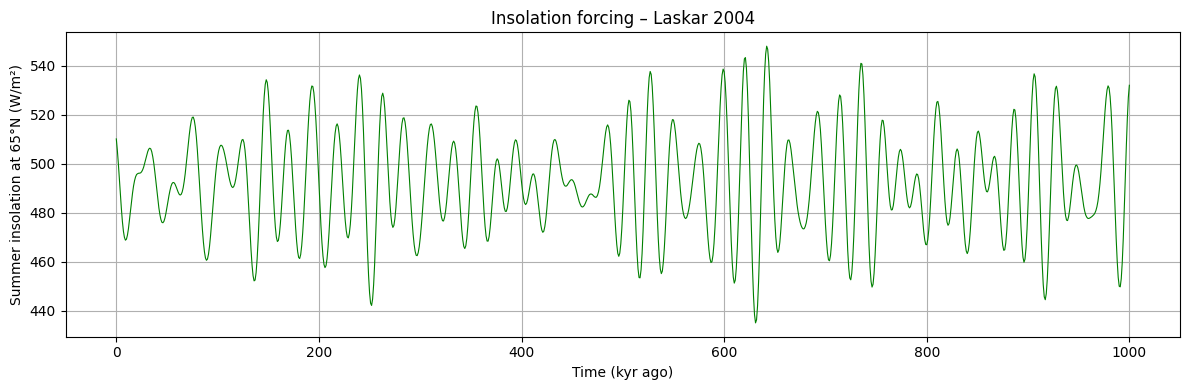

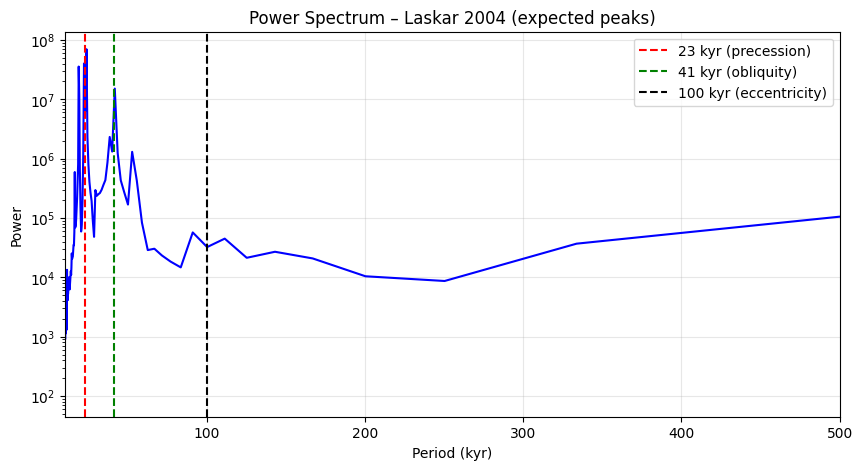

In [95]:
# plots 
plt.figure(figsize=(12, 4))
plt.plot(t_kyr_ref, Q_summer_ref, 'g-', linewidth=0.8)
plt.xlabel('Time (kyr ago)')
plt.ylabel('Summer insolation at 65°N (W/m²)')
plt.title('Insolation forcing – Laskar 2004')
plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 5))
plt.semilogy(period_kyr, power_ref, 'b-')
plt.xlim(10, 500)
plt.xlabel('Period (kyr)')
plt.ylabel('Power')
plt.title('Power Spectrum – Laskar 2004 (expected peaks)')
plt.axvline(23, color='r', linestyle='--', label='23 kyr (precession)')
plt.axvline(41, color='g', linestyle='--', label='41 kyr (obliquity)')
plt.axvline(100, color='k', linestyle='--', label='100 kyr (eccentricity)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [96]:
# Dominant periods
peaks, _ = find_peaks(power_ref, height=np.max(power_ref)*0.1)
dom_periods = period_kyr[peaks]
dom_power = power_ref[peaks]
sorted_idx = np.argsort(dom_power)[::-1]
print("\nDominant periods from Laskar 2004 (kyr):",
      dom_periods[sorted_idx][:5])


Dominant periods from Laskar 2004 (kyr): [23.83333333 22.24444444 18.88679245 41.70833333]


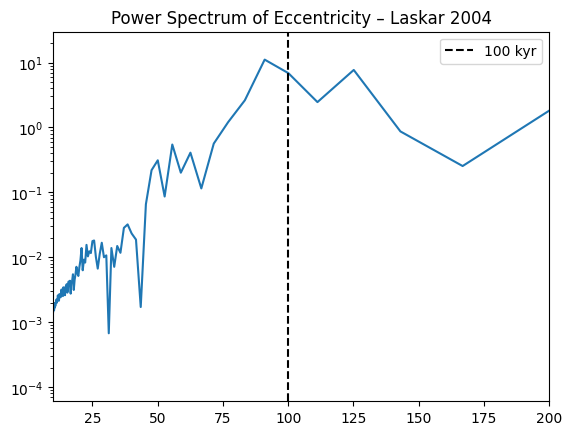

In [97]:
# Eccentricity spectrum (shows the 100 kyr peak clearly)
ecc_power_ref = np.abs(rfft(detrend(ecc_ref)))**2
plt.figure()
plt.semilogy(period_kyr, ecc_power_ref)
plt.xlim(10, 200)
plt.axvline(100, color='k', linestyle='--', label='100 kyr')
plt.legend()
plt.title('Power Spectrum of Eccentricity – Laskar 2004')
plt.show()

In [98]:
# Simulation Data - from our integrator
times = 100_000
steps_long = int(times / dt)

sim_file = "combined100k_data.txt"
if not os.path.exists(sim_file):
    print("Simulation data file not found. Running a 100 kyr simulation...")
    dt_sim = 0.02               
    steps = int(100_000 / dt_sim)
    ecc_sim = run_simulation(leapfrog_step, dt_sim, steps,
                             bodies='sun_earth_jupiter', eccentric_init=True)

    raise FileNotFoundError("Please provide combined100k_data.txt")
else:
    sim_data = np.loadtxt(sim_file)
    time_years_sim = sim_data[:, 0]   # years
    ecc_sim        = sim_data[:, 1]
    prec_sim       = sim_data[:, 2]
    obl_sim        = sim_data[:, 3]
    r_sim          = sim_data[:, 4]
    lon_sim        = sim_data[:, -1]

t_kyr_sim = time_years_sim / 1000.0
varpi_sim = np.arcsin(np.clip(prec_sim / ecc_sim, -1, 1))

In [99]:
r_solstice_sim = (1 - ecc_sim**2) / (1 + ecc_sim * np.cos(np.pi/2 - varpi_sim))
delta_solstice_sim = np.arcsin(np.sin(obl_sim) * np.sin(np.pi/2))
Q_summer_sim = daily_insolation(S0, r_solstice_sim, phi_65N, delta_solstice_sim)

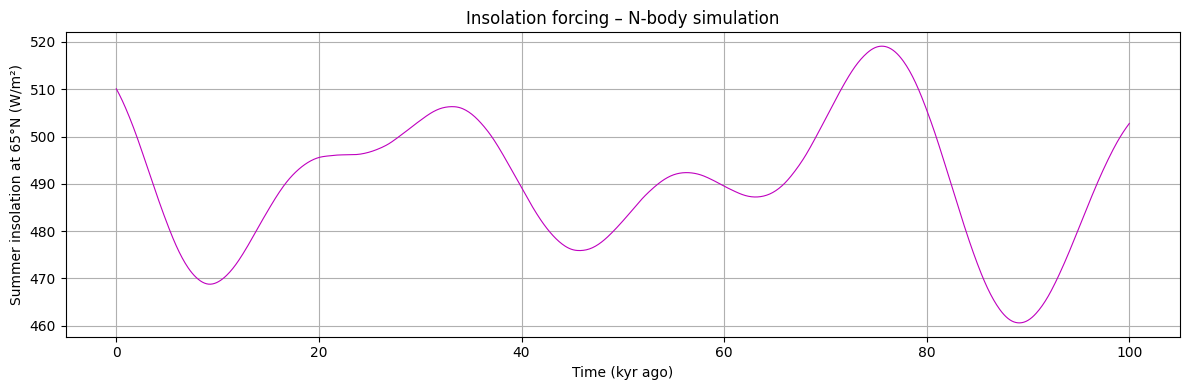

In [100]:
# show how summer insolation at 65°N changes over time due to orbital variations
plt.figure(figsize=(12, 4))
plt.plot(t_kyr_sim, Q_summer_sim, 'm-', linewidth=0.8)
plt.xlabel('Time (kyr ago)')
plt.ylabel('Summer insolation at 65°N (W/m²)')
plt.title('Insolation forcing – N‑body simulation')
plt.grid(True)
plt.tight_layout()
plt.show()

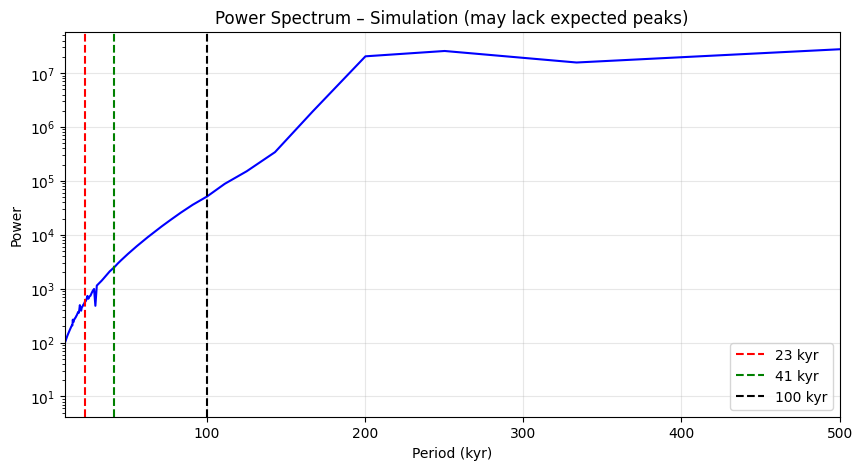

In [101]:
# Fourier analysis of simulated insolation
power_sim = np.abs(rfft(detrend(Q_summer_sim)))**2
plt.figure(figsize=(10, 5))
plt.semilogy(period_kyr[:len(power_sim)], power_sim, 'b-')
plt.xlim(10, 500)
plt.xlabel('Period (kyr)')
plt.ylabel('Power')
plt.title('Power Spectrum – Simulation (may lack expected peaks)')
plt.axvline(23, color='r', linestyle='--', label='23 kyr')
plt.axvline(41, color='g', linestyle='--', label='41 kyr')
plt.axvline(100, color='k', linestyle='--', label='100 kyr')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [102]:
peaks_sim, _ = find_peaks(power_sim, height=np.max(power_sim)*0.1)
dom_periods_sim = period_kyr[peaks_sim]
dom_power_sim = power_sim[peaks_sim]
sorted_idx_sim = np.argsort(dom_power_sim)[::-1]
print("\nDominant periods from simulation (kyr):",
      dom_periods_sim[sorted_idx_sim][:5])


Dominant periods from simulation (kyr): [500.5  250.25]


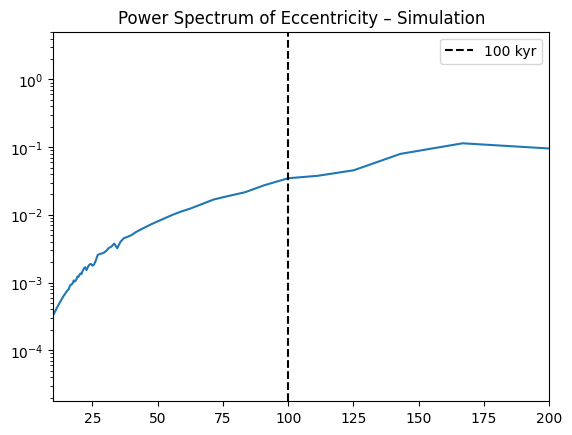

In [103]:
# Eccentricity spectrum from simulation
ecc_power_sim = np.abs(rfft(detrend(ecc_sim)))**2
plt.figure()
plt.semilogy(period_kyr[:len(ecc_power_sim)], ecc_power_sim)
plt.xlim(10, 200)
plt.axvline(100, color='k', linestyle='--', label='100 kyr')
plt.legend()
plt.title('Power Spectrum of Eccentricity – Simulation')
plt.show()


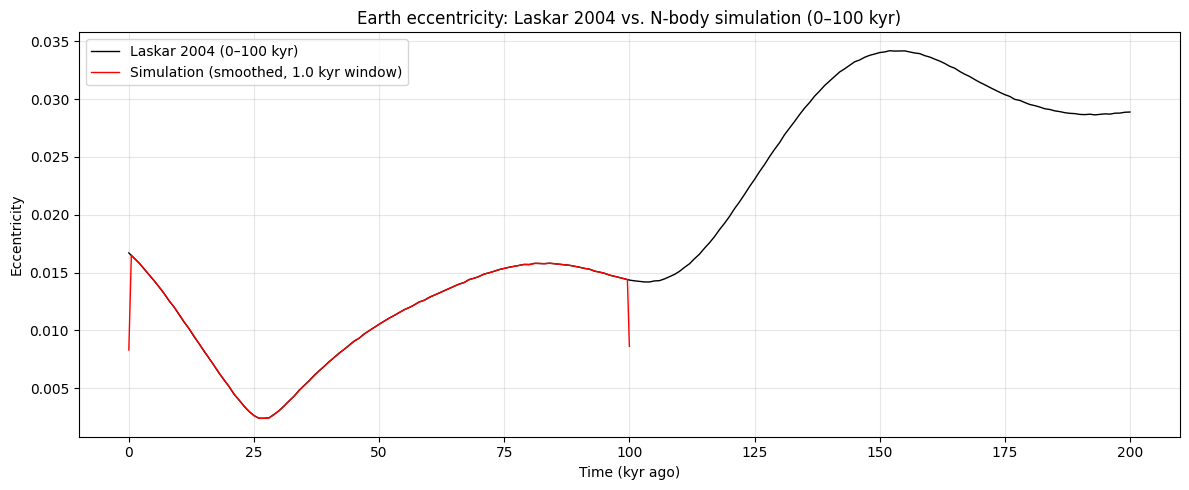

In [104]:
# COMPARISON: Eccentricity evolution

# Smooth the simulation data
window_kyr = 1.0                 # 1000 years smoothing
dt_sim_yr = time_years_sim[1] - time_years_sim[0]
window_size = int(window_kyr * 1000 / dt_sim_yr)
ecc_sim_smoothed = np.convolve(ecc_sim, np.ones(window_size)/window_size,
                               mode='same')

# Mask Laskar data to the first 200 kyr
mask = t_kyr_ref <= 200
t_laskar_masked = t_kyr_ref[mask]
ecc_laskar_masked = ecc_ref[mask]

# Plot both on the same time axis
plt.figure(figsize=(12, 5))
plt.plot(t_laskar_masked, ecc_laskar_masked, 'k-', linewidth=1, label='Laskar 2004 (0–100 kyr)')
plt.plot(t_kyr_sim, ecc_sim_smoothed, 'r-', linewidth=1,
         label=f'Simulation (smoothed, {window_kyr} kyr window)')
plt.xlabel('Time (kyr ago)')
plt.ylabel('Eccentricity')
plt.title('Earth eccentricity: Laskar 2004 vs. N‑body simulation (0–100 kyr)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


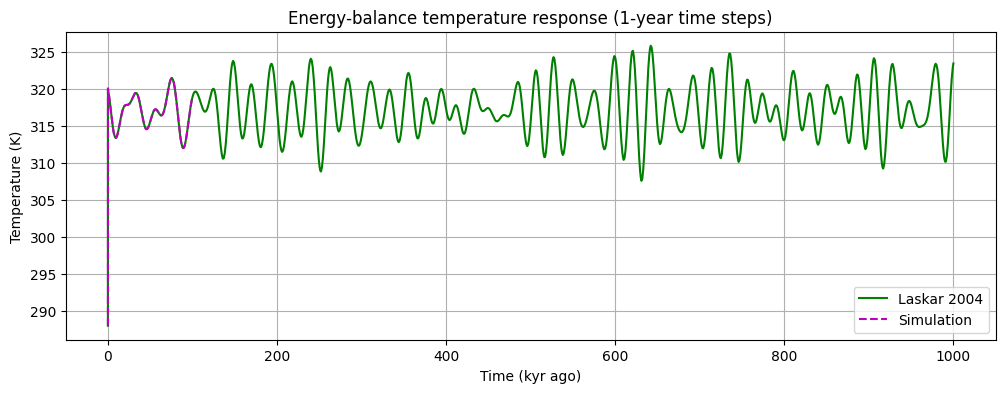

In [ ]:
# simple energy balance model to estimate temperature response to insolation changes at 65°N
sigma = 5.67e-8      # W/m²/K⁴
albedo = 0.3
epsilon = 0.6
C_heat = 4e8         # J/m²/K

def run_energy_balance(Q_summer, time_years, dt_years=1.0):
    # Interpolate insolation to a uniform fine grid
    t_fine = np.arange(time_years[0], time_years[-1], dt_years)
    Q_fine = interp1d(time_years, Q_summer, kind='linear', fill_value='extrapolate')(t_fine)
    
    T = np.zeros_like(Q_fine)
    T[0] = 288.0
    dt_seconds = dt_years * 365.25 * 24 * 3600
    
    for i in range(len(T)-1):
        E_in = (1 - albedo) * Q_fine[i]
        E_out = epsilon * sigma * T[i]**4
        dT = (E_in - E_out) / C_heat
        T[i+1] = T[i] + dT * dt_seconds
    
    return t_fine, T

t_ref_fine, T_ref = run_energy_balance(Q_summer_ref, t_kyr_ref * 1000, dt_years=1.0)
t_sim_fine, T_sim = run_energy_balance(Q_summer_sim, time_years_sim, dt_years=1.0)

plt.figure(figsize=(12,4))
plt.plot(t_ref_fine/1000, T_ref, 'g-', label='Laskar 2004')
plt.plot(t_sim_fine/1000, T_sim, 'm--', label='Simulation')
plt.xlabel('Time (kyr ago)')
plt.ylabel('Temperature (K)')
plt.title('Energy‑balance temperature response (1‑year time steps)')
plt.legend()
plt.grid(True)
plt.show()